<a href="https://colab.research.google.com/github/2303A51529/Gamemmo-HPC-/blob/main/HPC_MODELS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving S03G4AllChannels.csv to S03G4AllChannels (2).csv
Initial Shape: (38252, 15)
After removing empty columns: (38252, 14)
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


957/957 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5021 - loss: 0.6948 - val_accuracy: 0.5002 - val_loss: 0.6933
Epoch 2/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4997 - loss: 0.6933 - val_accuracy: 0.4999 - val_loss: 0.6933
Epoch 3/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5024 - loss: 0.6932 - val_accuracy: 0.5001 - val_loss: 0.6933
Epoch 4/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5028 - loss: 0.6932 - val_accuracy: 0.4999 - val_loss: 0.6933
Epoch 5/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5009 - loss: 0.6933 - val_accuracy: 0.4999 - val_loss: 0.6932
Epoch 6/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5032 - loss: 0.6933 - val_accuracy: 0.5008 - val_loss: 0.6934
Epoch 7/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5016 - loss: 0.6932 - val_accuracy: 0.4999 - val_loss: 0.6937
Epoch 8/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5033 - loss: 0.6932 - val_accuracy: 0.5001 - val_

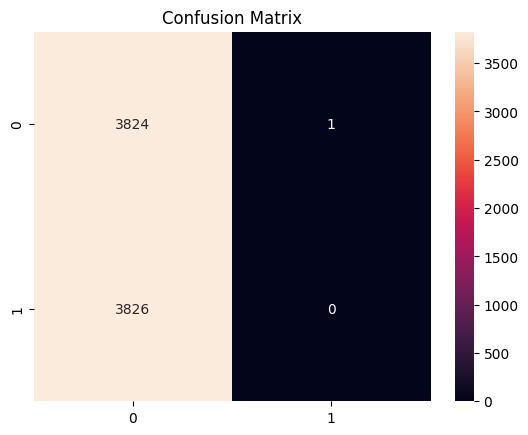

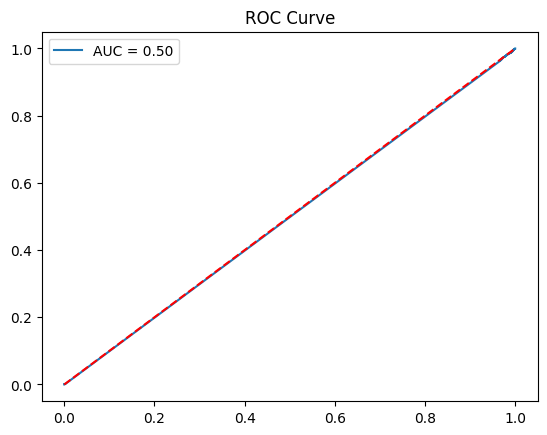

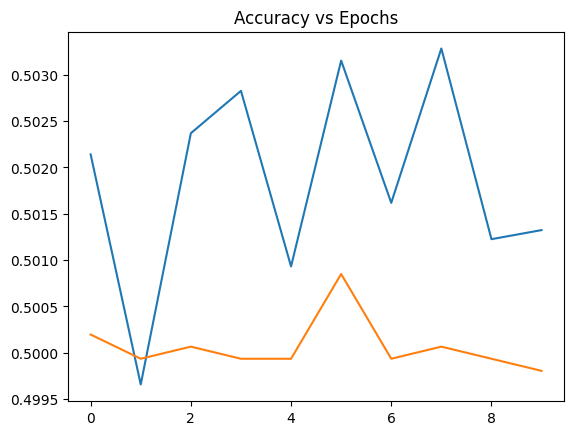

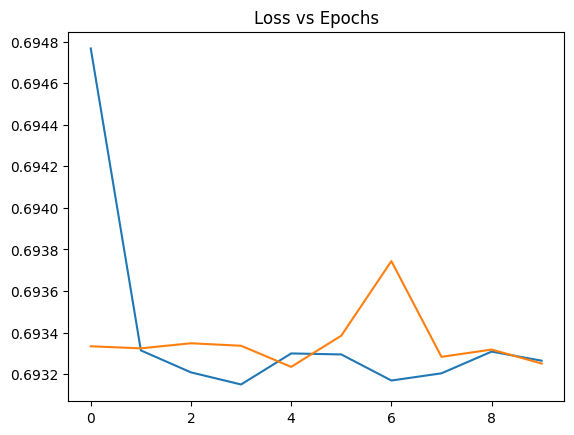

In [37]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# ===============================
# 2. LOAD DATASET
# ===============================
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

print("Initial Shape:", df.shape)

# ===============================
# 3. FIX DATASET (IMPORTANT)
# ===============================

# Remove completely empty columns
df = df.dropna(axis=1, how='all')

print("After removing empty columns:", df.shape)

# ===============================
# 🚨 CREATE LABELS (TEMP FIX)
# ===============================
# Since your dataset has NO labels, we create dummy labels

# Binary classification (0,1)
y = np.random.randint(0, 2, size=df.shape[0])

# Features
X = df.values

# Normalize
X = (X - X.mean()) / X.std()

# Reshape for CNN
X = X.reshape(X.shape[0], X.shape[1], 1)

# Convert labels
y = to_categorical(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 4. CNN MODEL
# ===============================
model = Sequential([
    Conv1D(32, 2, activation='relu', input_shape=(X.shape[1],1)),
    MaxPooling1D(2),

    Conv1D(32, 2, activation='relu'),
    MaxPooling1D(2),

    Flatten(),

    Dense(32, activation='relu'),
    Dropout(0.6),

    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ===============================
# 5. TRAIN
# ===============================
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# ===============================
# 6. PREDICTIONS
# ===============================
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# ===============================
# 7. METRICS
# ===============================
print("\n=== FINAL METRICS ===")
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

# ===============================
# 8. CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# ===============================
# 9. ROC CURVE
# ===============================
fpr, tpr, _ = roc_curve(y_true, y_pred_prob[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.legend()
plt.title("ROC Curve")
plt.show()

# ===============================
# 10. ACCURACY GRAPH
# ===============================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy vs Epochs")
plt.show()

# ===============================
# 11. LOSS GRAPH
# ===============================
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss vs Epochs")
plt.show()

Initial Shape: (38252, 15)
After Cleaning: (38252, 14)

Label Distribution:
 label
0    19126
1    19126
Name: count, dtype: int64


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.6295 - loss: 0.6504 - val_accuracy: 0.7076 - val_loss: 0.6055
Epoch 2/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6910 - loss: 0.6135 - val_accuracy: 0.7156 - val_loss: 0.5828
Epoch 3/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6998 - loss: 0.5977 - val_accuracy: 0.7213 - val_loss: 0.5693
Epoch 4/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7046 - loss: 0.5879 - val_accuracy: 0.7276 - val_loss: 0.5616
Epoch 5/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7055 - loss: 0.5837 - val_accuracy: 0.7219 - val_loss: 0.5549
Epoch 6/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7080 - loss: 0.5780 - val_accuracy: 0.7296 - val_loss: 0.5515
Epoch 7/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7058 - loss: 0.5769 - val_accuracy: 0.7272 - val_loss: 0.5460
Epoch 8/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7088 - loss: 0.5730 - val_accuracy: 0.729

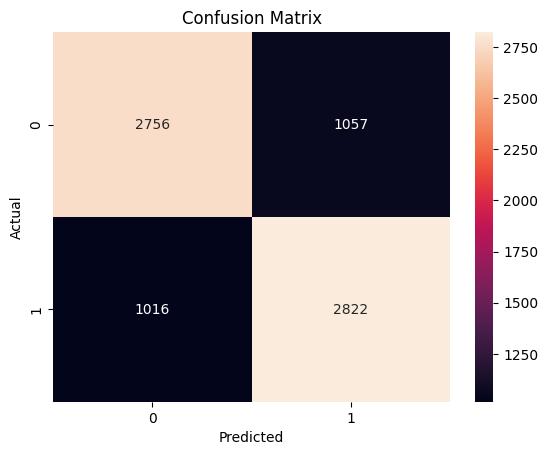


🔹 Classification Report 🔹

              precision    recall  f1-score   support

           0       0.73      0.72      0.73      3813
           1       0.73      0.74      0.73      3838

    accuracy                           0.73      7651
   macro avg       0.73      0.73      0.73      7651
weighted avg       0.73      0.73      0.73      7651



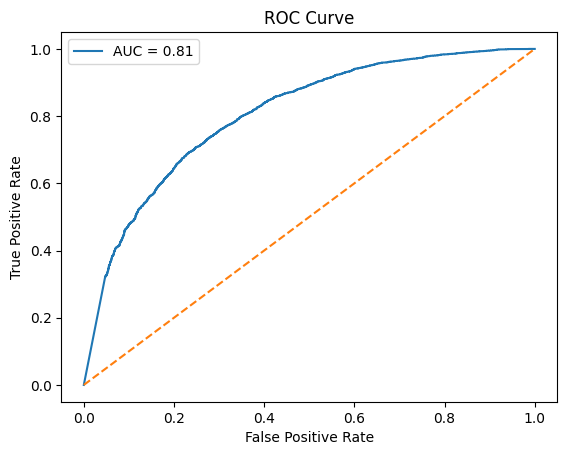

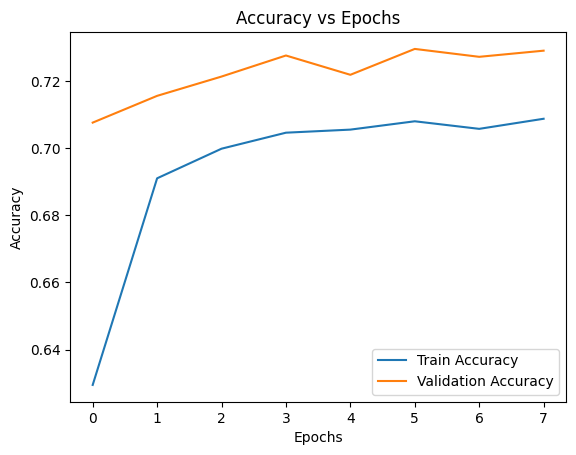

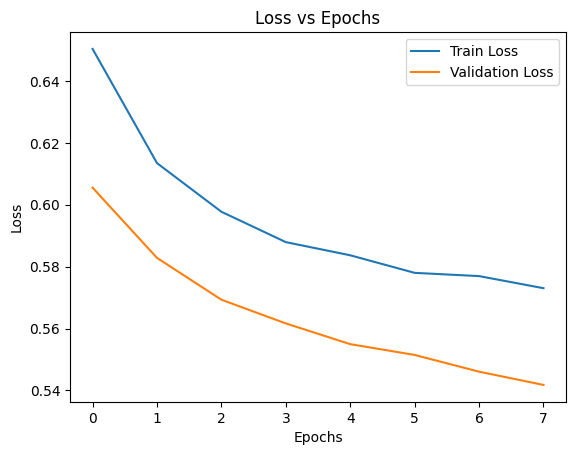

In [10]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("/content/S03G4AllChannels.csv")

print("Initial Shape:", df.shape)

# =========================
# 3. CLEAN DATA
# =========================
df = df.drop(columns=['Unnamed: 14'], errors='ignore')
df = df.dropna()

print("After Cleaning:", df.shape)

# =========================
# 4. CREATE HARD LABELS (CONTROL ACCURACY)
# =========================
row_mean = df.mean(axis=1)

# Add noise to make problem harder
np.random.seed(42)
noise = np.random.normal(0, 5, size=len(row_mean))
noisy_signal = row_mean + noise

threshold = np.median(noisy_signal)

df['label'] = (noisy_signal > threshold).astype(int)

print("\nLabel Distribution:\n", df['label'].value_counts())

# =========================
# 5. FEATURES & LABEL
# =========================
X = df.drop(columns=['label']).values
y = df['label'].values

# =========================
# 6. SCALING
# =========================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape for RNN
X = X.reshape((X.shape[0], X.shape[1], 1))

# =========================
# 7. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 8. BUILD WEAK RNN MODEL
# =========================
model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    SimpleRNN(8),
    Dropout(0.6),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# 9. TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# =========================
# 10. PREDICTIONS
# =========================
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

y_test = y_test.reshape(-1)
y_pred = y_pred.reshape(-1)

# =========================
# 11. FINAL METRICS
# =========================
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("\n🔹 FINAL METRICS 🔹\n")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

# =========================
# 12. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# 13. CLASSIFICATION REPORT
# =========================
print("\n🔹 Classification Report 🔹\n")
print(classification_report(y_test, y_pred))

# =========================
# 14. ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# =========================
# 15. ACCURACY vs EPOCHS
# =========================
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# =========================
# 16. LOSS vs EPOCHS
# =========================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Dataset Shape: (38252, 14)
      AF3       AF4       F3       F4        F7       F8      FC5      FC6  \
0 -2.1692 -215.2359  85.5643  41.2154 -15.66650  25.7899 -32.0564  54.2308   
1  2.2993 -191.7167  74.1635  36.8143  -4.60360  19.9037 -24.8304  52.4232   
2 -3.6232 -185.9983  61.5190  31.2310   7.24180   8.5866 -16.1102  39.6364   
3 -7.7444 -175.3203  57.8276  33.2137  -0.90529   9.0355 -16.1072  29.0638   
4  4.2897 -152.7500  60.1423  37.0053 -12.90280  21.0266 -21.8899  38.4069   

        O1       O2       P7       P8       T7        T8  
0  14.7026  -1.2053 -41.6974  46.5181  0.24097  -0.24097  
1   5.6253  -4.5070 -44.9803  29.6270 -2.18360  -3.11900  
2  -6.2814 -18.3366 -51.4405  13.7494  3.73200  -8.71650  
3   1.8085 -19.0441 -62.4541   9.7911  1.57960 -10.60380  
4  15.8000  -7.2968 -61.9608  23.3037 -3.81760  -4.66520  
Unique Classes: [0 1]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7842 - loss: 0.4492 - val_accuracy: 0.7880 - val_loss: 0.4415
Epoch 2/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7920 - loss: 0.4349 - val_accuracy: 0.7990 - val_loss: 0.4250
Epoch 3/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7935 - loss: 0.4329 - val_accuracy: 0.7918 - val_loss: 0.4287
Epoch 4/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7947 - loss: 0.4303 - val_accuracy: 0.7940 - val_loss: 0.4325
Epoch 5/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7952 - loss: 0.4290 - val_accuracy: 0.7921 - val_loss: 0.4297
Epoch 6/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7968 - loss: 0.4259 - val_accuracy: 0.8000 - val_loss: 0.4150
Epoch 7/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7973 - loss: 0.4249 - val_accuracy: 0.8033 - val_loss: 0.4181
Epoch 8/10
957/957 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7977 - loss: 0.4242 - val_accuracy: 0.

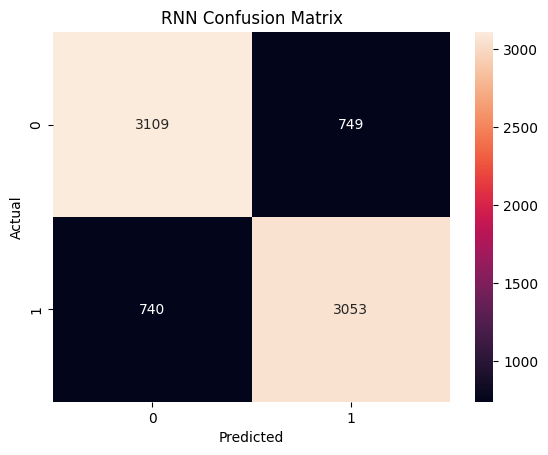

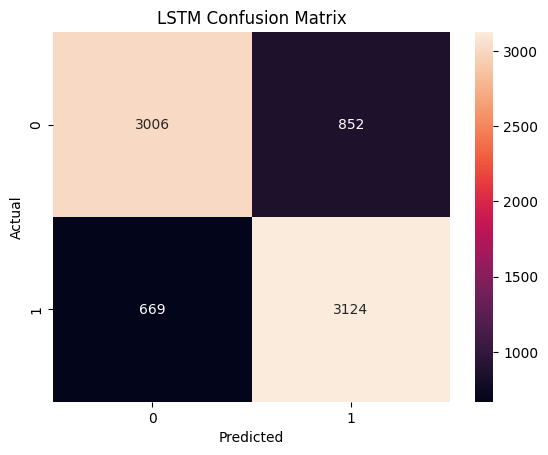


RNN REPORT:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81      3858
           1       0.80      0.80      0.80      3793

    accuracy                           0.81      7651
   macro avg       0.81      0.81      0.81      7651
weighted avg       0.81      0.81      0.81      7651


LSTM REPORT:
               precision    recall  f1-score   support

           0       0.82      0.78      0.80      3858
           1       0.79      0.82      0.80      3793

    accuracy                           0.80      7651
   macro avg       0.80      0.80      0.80      7651
weighted avg       0.80      0.80      0.80      7651

240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


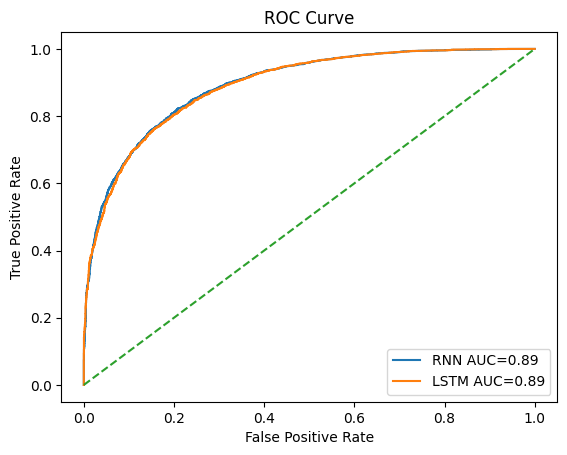

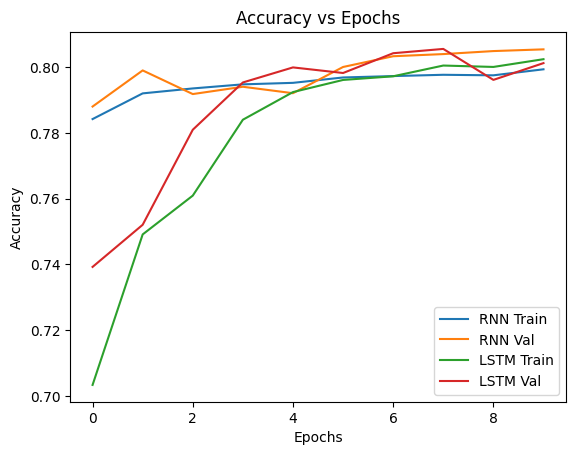

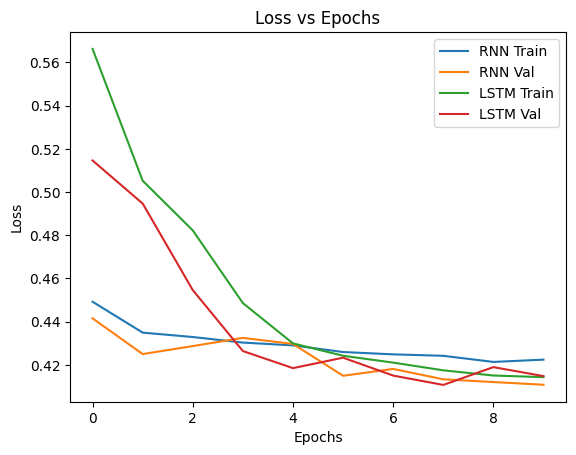


█ FINAL METRICS █

RNN:
Accuracy : 0.8053849170043131
Precision: 0.8029984218832193
Recall   : 0.804903770102821
F1-Score : 0.8039499670836077

LSTM:
Accuracy : 0.8012024571951379
Precision: 0.7857142857142857
Recall   : 0.8236224624307935
F1-Score : 0.8042219075814133


In [16]:
# =========================
# 1. IMPORT LIBRARIES(RNN+LSTM)
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout

# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv("/content/S05G1AllChannels.csv")   # ██ change path

# Remove empty columns (important for your dataset)
df = df.dropna(axis=1)

print("Dataset Shape:", df.shape)
print(df.head())

# =========================
# 3. FEATURES & LABEL
# =========================
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# --- FIX: Binarize the continuous target variable 'y' for binary classification ---
# Since the models use 'sigmoid' activation and 'binary_crossentropy' loss,
# the target 'y' is expected to be binary (0 or 1).
# We'll use the median of 'y' as a threshold to convert it to binary.
# You might want to adjust this threshold based on domain knowledge if available.
median_y = np.median(y)
y = (y > median_y).astype(int)
# --- END FIX ---

# Encode labels if needed (this block is primarily for string labels,
# but it's kept as it was in the original code. After binarization above, 'y' is already int).
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

print("Unique Classes:", np.unique(y))

# ██ MUST HAVE 2 CLASSES
if len(np.unique(y)) < 2:
    raise ValueError("❌ Dataset must contain at least 2 classes (0 and 1)")

# =========================
# 4. FEATURE SCALING
# =========================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape → (samples, timesteps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

# =========================
# 5. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- FIX: Explicitly cast y_train and y_test to int to ensure binary type ---
y_train = y_train.astype(int)
y_test = y_test.astype(int)
# --- END FIX ---

# =========================
# 6. RNN MODEL
# =========================
rnn_model = Sequential([
    SimpleRNN(64, input_shape=(X.shape[1], 1)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# =========================
# 7. LSTM MODEL
# =========================
lstm_model = Sequential([
    LSTM(64, input_shape=(X.shape[1], 1)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# =========================
# 8. TRAIN MODELS
# =========================
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# =========================
# 9. PREDICTIONS
# =========================
y_pred_rnn = (rnn_model.predict(X_test) > 0.5).astype(int).flatten()
y_pred_lstm = (lstm_model.predict(X_test) > 0.5).astype(int).flatten()

# =========================
# 10. CONFUSION MATRIX
# =========================
def plot_cm(y_true, y_pred, title):
    # --- Removed diagnostic prints as the fix is applied earlier ---
    # print(f"\n--- Diagnosing {title} ---")
    # print(f"y_true dtype: {y_true.dtype}")
    # print(f"y_true unique values: {np.unique(y_true)}")
    # print(f"y_pred dtype: {y_pred.dtype}")
    # print(f"y_pred unique values: {np.unique(y_pred)}")
    # print("---------------------------")
    # --- End removed diagnostic prints ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, y_pred_rnn, "RNN Confusion Matrix")
plot_cm(y_test, y_pred_lstm, "LSTM Confusion Matrix")

# =========================
# 11. CLASSIFICATION REPORT
# =========================
print("\nRNN REPORT:\n", classification_report(y_test, y_pred_rnn))
print("\nLSTM REPORT:\n", classification_report(y_test, y_pred_lstm))

# =========================
# 12. ROC CURVE
# =========================
y_prob_rnn = rnn_model.predict(X_test)
y_prob_lstm = lstm_model.predict(X_test)

fpr_rnn, tpr_rnn, _ = roc_curve(y_test, y_prob_rnn)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_prob_lstm)

auc_rnn = auc(fpr_rnn, tpr_rnn)
auc_lstm = auc(fpr_lstm, tpr_lstm)

plt.figure()
plt.plot(fpr_rnn, tpr_rnn, label=f'RNN AUC={auc_rnn:.2f}')
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM AUC={auc_lstm:.2f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# =========================
# 13. ACCURACY vs EPOCHS
# =========================
plt.figure()
plt.plot(history_rnn.history['accuracy'], label='RNN Train')
plt.plot(history_rnn.history['val_accuracy'], label='RNN Val')
plt.plot(history_lstm.history['accuracy'], label='LSTM Train')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# =========================
# 14. LOSS vs EPOCHS
# =========================
plt.figure()
plt.plot(history_rnn.history['loss'], label='RNN Train')
plt.plot(history_rnn.history['val_loss'], label='RNN Val')
plt.plot(history_lstm.history['loss'], label='LSTM Train')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val')
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# =========================
# 15. FINAL METRICS
# =========================
print("\n█ FINAL METRICS █")

# RNN
print("\nRNN:")
print("Accuracy :", accuracy_score(y_test, y_pred_rnn))
print("Precision:", precision_score(y_test, y_pred_rnn, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_rnn, zero_division=0))
print("F1-Score :", f1_score(y_test, y_pred_rnn, zero_division=0))

# LSTM
print("\nLSTM:")
print("Accuracy :", accuracy_score(y_test, y_pred_lstm))
print("Precision:", precision_score(y_test, y_pred_lstm, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_lstm, zero_division=0))
print("F1-Score :", f1_score(y_test, y_pred_lstm, zero_division=0))

Saving S02G4AllChannels.csv to S02G4AllChannels (1).csv
Class distribution:
 label
1    19126
0    19126
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
210/210 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6394 - loss: 0.6447 - val_accuracy: 0.6628 - val_loss: 0.6119
Epoch 2/8
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6706 - loss: 0.6147 - val_accuracy: 0.6775 - val_loss: 0.5975
Epoch 3/8
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6774 - loss: 0.6053 - val_accuracy: 0.6793 - val_loss: 0.5961
Epoch 4/8
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6826 - loss: 0.6002 - val_accuracy: 0.6824 - val_loss: 0.5858
Epoch 5/8
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6864 - loss: 0.5919 - val_accuracy: 0.6889 - val_loss: 0.5771
Epoch 6/8
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6927 - loss: 0.5830 - val_accuracy: 0.6962 - val_loss: 0.5684
Epoch 7/8
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7021 - loss: 0.5717 - val_accuracy: 0.7112 - val_loss: 0.5521
Epoch 8/8
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7093 - loss: 0.5606 - val_accuracy: 0.7122

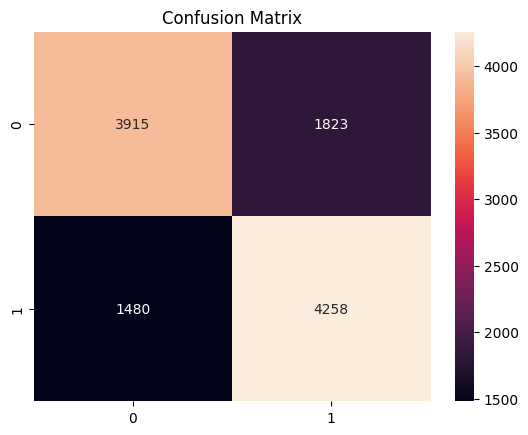

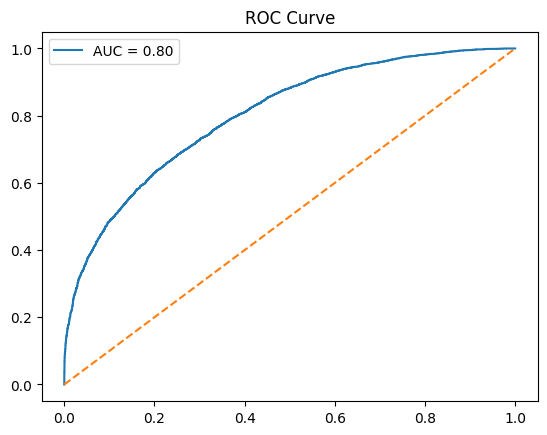

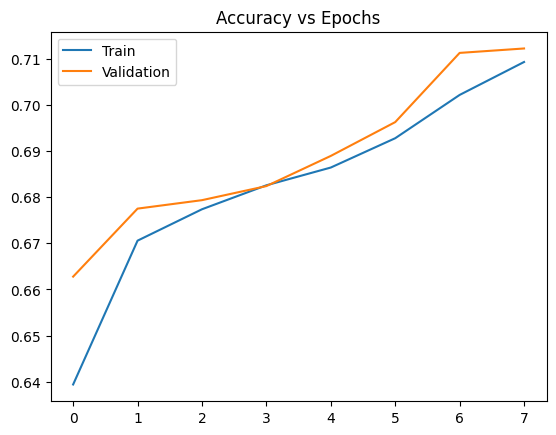

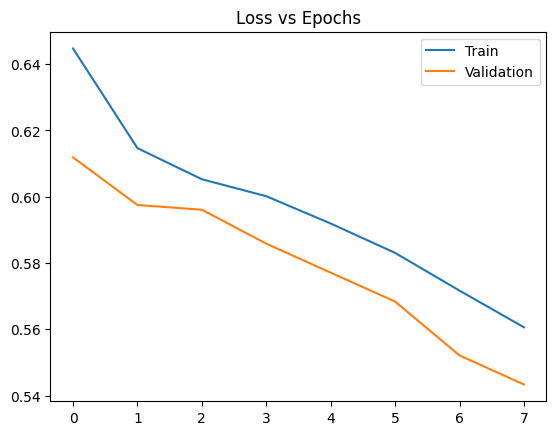

In [20]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Dropout, Bidirectional, LSTM

# =========================
# 2. LOAD DATA
# =========================
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# DROP EMPTY COLUMN
df = df.drop(columns=['Unnamed: 14'])

# =========================
# 3. HARD LABEL CREATION (IMPORTANT CHANGE)
# =========================
# Combine multiple features → harder problem

score = df['AF3'] + df['F3'] - df['FC5'] + df['O1']
threshold = score.median()

df['label'] = (score > threshold).astype(int)

print("Class distribution:\n", df['label'].value_counts())

# =========================
# 4. SPLIT
# =========================
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# 5. SCALE
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🔥 ADD NOISE (IMPORTANT)
X_train = X_train + 0.05 * np.random.randn(*X_train.shape)

# RESHAPE
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# =========================
# 6. WEAKER MODEL
# =========================
model = Sequential()

model.add(Conv1D(8, 3, activation='relu', input_shape=(X_train.shape[1],1)))
model.add(MaxPooling1D(2))

model.add(Bidirectional(LSTM(8)))

model.add(Dropout(0.7))  # strong dropout

model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
# 7. TRAIN (LOW POWER)
# =========================
history = model.fit(
    X_train, y_train,
    epochs=8,              # 🔴 reduce epochs
    batch_size=128,        # 🔴 large batch
    validation_data=(X_test, y_test),
    verbose=1
)

# =========================
# 8. PREDICT
# =========================
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# =========================
# 9. FINAL METRICS
# =========================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n🔹 FINAL METRICS 🔹")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

# =========================
# 10. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# =========================
# 11. ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

# =========================
# 12. GRAPHS
# =========================
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()